# Normal Equation

## Learning Objectives
- Understand the Normal Equation as the **closed-form analytical solution** to linear regression
- Derive $\boldsymbol{\theta}^* = (X^\top X)^{-1} X^\top \mathbf{y}$ from first principles by setting $\nabla_{\boldsymbol{\theta}} J = 0$
- Understand when $X^\top X$ is invertible and what to do when it is not (pseudoinverse / ridge)
- Know the $O(n^3)$ computational cost and when to prefer the Normal Equation over gradient descent
- Implement `solve_normal_equation` and `predict_normal_equation` in NumPy

## Problem Statement

Given a training set of $m$ examples with design matrix $X \in \mathbb{R}^{m \times (n+1)}$ and targets $\mathbf{y} \in \mathbb{R}^m$, find $\boldsymbol{\theta} \in \mathbb{R}^{n+1}$ that minimizes:

$\displaystyle J(\boldsymbol{\theta}) = \frac{1}{2m} \|\mathbf{y} - X\boldsymbol{\theta}\|^2 = \frac{1}{2m}(\mathbf{y} - X\boldsymbol{\theta})^\top(\mathbf{y} - X\boldsymbol{\theta})$

---

### Gradient Descent vs Normal Equation

Gradient descent finds $\boldsymbol{\theta}^*$ iteratively — it approximates. The Normal Equation finds it **exactly in one step** by solving $\nabla_{\boldsymbol{\theta}} J = 0$ directly.

| Property | Gradient Descent | Normal Equation |
|---|---|---|
| Solution | Iterative (many steps) | Closed-form (one step) |
| Learning rate $\alpha$ | Must be chosen | Not needed |
| Cost per step | $O(mn)$ | $O(n^3)$ (matrix inversion) |
| Scales with $m$ | Well | Well |
| Scales with $n$ | Well | Poorly ($n \gtrsim 10^4$ is slow) |
| Feature scaling | Required | Not required |
| Non-invertible $X^\top X$ | Always works | Needs pseudoinverse |

---

### Core Idea

At the minimum of a convex function, the gradient is zero. Set $\nabla_{\boldsymbol{\theta}} J = 0$ and solve analytically:

$\displaystyle \boldsymbol{\theta}^* = (X^\top X)^{-1} X^\top \mathbf{y}$

This is the **Normal Equation**. No iterations, no learning rate — just one matrix solve.

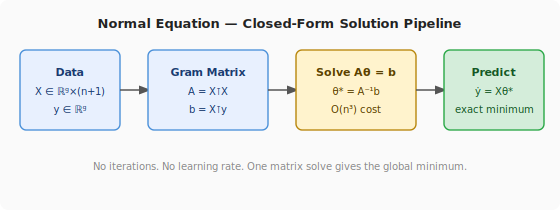

In [3]:
from IPython.display import SVG, display

svg = """
<svg xmlns="http://www.w3.org/2000/svg" width="560" height="210" viewBox="0 0 560 210">
  <rect width="560" height="210" fill="#fafafa" rx="8"/>

  <text x="280" y="28" text-anchor="middle" font-size="13" font-weight="bold" fill="#222">Normal Equation — Closed-Form Solution Pipeline</text>

  <!-- Box 1: Data -->
  <rect x="20"  y="50" width="100" height="80" rx="6" fill="#e8f0fe" stroke="#4a90d9" stroke-width="1.4"/>
  <text x="70"  y="76"  text-anchor="middle" font-size="11" font-weight="bold" fill="#1a3a6e">Data</text>
  <text x="70"  y="95"  text-anchor="middle" font-size="10" fill="#1a3a6e">X &#x2208; &#x211D;&#x1D4D;&#xD7;&#x28;n+1&#x29;</text>
  <text x="70"  y="113" text-anchor="middle" font-size="10" fill="#1a3a6e">y &#x2208; &#x211D;&#x1D4D;</text>

  <!-- Arrow 1 -->
  <line x1="120" y1="90" x2="148" y2="90" stroke="#555" stroke-width="1.5" marker-end="url(#arr)"/>

  <!-- Box 2: Gram Matrix -->
  <rect x="148" y="50" width="120" height="80" rx="6" fill="#e8f0fe" stroke="#4a90d9" stroke-width="1.4"/>
  <text x="208" y="76"  text-anchor="middle" font-size="11" font-weight="bold" fill="#1a3a6e">Gram Matrix</text>
  <text x="208" y="95"  text-anchor="middle" font-size="10" fill="#1a3a6e">A = X&#x22BA;X</text>
  <text x="208" y="113" text-anchor="middle" font-size="10" fill="#1a3a6e">b = X&#x22BA;y</text>

  <!-- Arrow 2 -->
  <line x1="268" y1="90" x2="296" y2="90" stroke="#555" stroke-width="1.5" marker-end="url(#arr)"/>

  <!-- Box 3: Solve -->
  <rect x="296" y="50" width="120" height="80" rx="6" fill="#fff3cd" stroke="#b8860b" stroke-width="1.4"/>
  <text x="356" y="76"  text-anchor="middle" font-size="11" font-weight="bold" fill="#5a4000">Solve A&#x03B8; = b</text>
  <text x="356" y="95"  text-anchor="middle" font-size="10" fill="#5a4000">&#x03B8;* = A&#x207B;&#xB9;b</text>
  <text x="356" y="113" text-anchor="middle" font-size="10" fill="#5a4000">O(n&#xB3;) cost</text>

  <!-- Arrow 3 -->
  <line x1="416" y1="90" x2="444" y2="90" stroke="#555" stroke-width="1.5" marker-end="url(#arr)"/>

  <!-- Box 4: Predict -->
  <rect x="444" y="50" width="100" height="80" rx="6" fill="#d4edda" stroke="#28a745" stroke-width="1.4"/>
  <text x="494" y="76"  text-anchor="middle" font-size="11" font-weight="bold" fill="#155724">Predict</text>
  <text x="494" y="95"  text-anchor="middle" font-size="10" fill="#155724">&#x1E8F; = X&#x03B8;*</text>
  <text x="494" y="113" text-anchor="middle" font-size="10" fill="#155724">exact minimum</text>

  <!-- Bottom note -->
  <text x="280" y="170" text-anchor="middle" font-size="10" fill="#888">No iterations. No learning rate. One matrix solve gives the global minimum.</text>

  <!-- Arrowhead marker -->
  <defs>
    <marker id="arr" markerWidth="8" markerHeight="8" refX="6" refY="3" orient="auto">
      <path d="M0,0 L0,6 L8,3 z" fill="#555"/>
    </marker>
  </defs>
</svg>
"""

display(SVG(svg))

## Hypothesis Function

For a single example $x \in \mathbb{R}^{n+1}$ (with $x_0 = 1$ prepended):

$\displaystyle h_{\boldsymbol{\theta}}(x) = \boldsymbol{\theta}^\top x = \theta_0 x_0 + \theta_1 x_1 + \cdots + \theta_n x_n$

In vectorized form over the full design matrix $X \in \mathbb{R}^{m \times (n+1)}$:

$\displaystyle \hat{\mathbf{y}} = X\boldsymbol{\theta}$

where

$\displaystyle X = \begin{bmatrix} 1 & x_1^{(1)} & \cdots & x_n^{(1)} \\ 1 & x_1^{(2)} & \cdots & x_n^{(2)} \\ \vdots & \vdots & \ddots & \vdots \\ 1 & x_1^{(m)} & \cdots & x_n^{(m)} \end{bmatrix}, \quad \boldsymbol{\theta} = \begin{bmatrix} \theta_0 \\ \theta_1 \\ \vdots \\ \theta_n \end{bmatrix}, \quad \mathbf{y} = \begin{bmatrix} y^{(1)} \\ y^{(2)} \\ \vdots \\ y^{(m)} \end{bmatrix}$

## Derivation

**High-level steps:**
1. Expand $J(\boldsymbol{\theta})$ in matrix form
2. Compute the gradient $\nabla_{\boldsymbol{\theta}} J$
3. Set $\nabla_{\boldsymbol{\theta}} J = \mathbf{0}$ (necessary condition for minimum)
4. Solve for $\boldsymbol{\theta}^*$

---

**Step 1 — Expand the cost in matrix form**

$\displaystyle J(\boldsymbol{\theta}) = \frac{1}{2m}(\mathbf{y} - X\boldsymbol{\theta})^\top(\mathbf{y} - X\boldsymbol{\theta})$

$\displaystyle = \frac{1}{2m}\bigl(\mathbf{y}^\top\mathbf{y} - 2\boldsymbol{\theta}^\top X^\top \mathbf{y} + \boldsymbol{\theta}^\top X^\top X \boldsymbol{\theta}\bigr)$

(using the identity $\mathbf{y}^\top X\boldsymbol{\theta} = \boldsymbol{\theta}^\top X^\top \mathbf{y}$ since both are scalars)

---

**Step 2 — Compute the gradient**

Using matrix calculus identities $\nabla_{\boldsymbol{\theta}}(A^\top \boldsymbol{\theta}) = A$ and $\nabla_{\boldsymbol{\theta}}(\boldsymbol{\theta}^\top B \boldsymbol{\theta}) = 2B\boldsymbol{\theta}$ (for symmetric $B$):

$\displaystyle \nabla_{\boldsymbol{\theta}} J = \frac{1}{m}\bigl(-X^\top \mathbf{y} + X^\top X \boldsymbol{\theta}\bigr)$

---

**Step 3 — Set gradient to zero**

$\displaystyle \frac{1}{m}\bigl(X^\top X \boldsymbol{\theta} - X^\top \mathbf{y}\bigr) = \mathbf{0}$

$\displaystyle X^\top X \boldsymbol{\theta} = X^\top \mathbf{y}$

This is the **Normal Equations** (a linear system in $\boldsymbol{\theta}$).

---

**Step 4 — Solve for $\boldsymbol{\theta}^*$**

If $X^\top X$ is invertible (i.e., $X$ has full column rank):

$\displaystyle \boldsymbol{\theta}^* = (X^\top X)^{-1} X^\top \mathbf{y}$

If $X^\top X$ is singular (linearly dependent features or $m < n+1$), use the **Moore-Penrose pseudoinverse**:

$\displaystyle \boldsymbol{\theta}^* = X^\dagger \mathbf{y}, \quad X^\dagger = \lim_{\lambda \to 0}(X^\top X + \lambda I)^{-1} X^\top$

## Solve Phase

**Step 1 — Prepare the design matrix**
Prepend a column of ones to $X$ to absorb the bias term $\theta_0$, giving $X \in \mathbb{R}^{m \times (n+1)}$.

**Step 2 — Compute the Gram matrix and right-hand side**

$\displaystyle A = X^\top X \in \mathbb{R}^{(n+1) \times (n+1)}, \qquad \mathbf{b} = X^\top \mathbf{y} \in \mathbb{R}^{n+1}$

**Step 3 — Solve the linear system**

$\displaystyle A\,\boldsymbol{\theta}^* = \mathbf{b}$

Prefer `np.linalg.solve(A, b)` over explicit inversion `np.linalg.inv(A) @ b` — it is numerically more stable and avoids forming $A^{-1}$ explicitly.

**Step 4 — Use the learned parameters**
The resulting $\boldsymbol{\theta}^*$ is the **exact global minimum** of $J$. Predict on new input $x$:

$\displaystyle \hat{y} = h_{\boldsymbol{\theta}^*}(x) = x^\top \boldsymbol{\theta}^*$

## Prediction Phase

**Step 1 — Prepare the input**
Prepend $x_0 = 1$ to each new example so the input matches the shape of $\boldsymbol{\theta}^*$.

**Step 2 — Apply the hypothesis function**

$\displaystyle \hat{\mathbf{y}} = X_{\text{new}}\,\boldsymbol{\theta}^*$

where $X_{\text{new}} \in \mathbb{R}^{p \times (n+1)}$ holds the $p$ new examples with the bias column prepended.

**Step 3 — Return predictions**
$\hat{\mathbf{y}} \in \mathbb{R}^p$ contains one predicted value per new example.

In [ ]:
import numpy as np

def solve_normal_equation(X, y):
    """
    Inputs
    ------
    X : np.ndarray, shape (m, n+1)  — design matrix with bias column (x_0 = 1) prepended
    y : np.ndarray, shape (m,)      — target values

    Output
    ------
    theta : np.ndarray, shape (n+1,)  — exact optimal parameter vector θ* = (X⊤X)⁻¹X⊤y
    """
    # np.linalg.solve is preferred over inv(A) @ b for numerical stability
    return np.linalg.solve(X.T @ X, X.T @ y)


def predict_normal_equation(X_new, theta):
    """
    Inputs
    ------
    X_new : np.ndarray, shape (p, n+1)  — new examples with bias column (x_0 = 1) prepended
    theta : np.ndarray, shape (n+1,)    — learned parameter vector returned by solve_normal_equation

    Output
    ------
    y_hat : np.ndarray, shape (p,)  — predicted values for each of the p examples
    """
    return X_new @ theta

: 